# Final Assignment

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set(rc={'figure.figsize':(15, 9)})
sns.set(font_scale=1.5)

## Executive Summary

This analysis explores food consumption patterns and CO₂ emissions across countries using descriptive statistics, visualization, and hypothesis testing.

Key findings:

- **Beef shows the highest variability in CO₂ emissions**, as confirmed by the Interquartile Range (IQR), indicating strong differences across countries.
- **Poultry consumption is significantly higher than fish consumption**, supported by a one-sided permutation test (p-value ≈ 0.03).
- **Distributions were classified using both visual and quantitative criteria**, including symmetry and mean-median comparison for normality.

Overall, the analysis combines visual inspection with statistical validation to ensure robust and reliable conclusions.

## Methodology

The analysis follows a structured approach:

1. **Data exploration** to understand the structure and key variables.
2. **Descriptive statistics** to summarize central tendency and variability.
3. **Data visualization** to identify patterns and compare distributions.
4. **Statistical inference** using a permutation test to validate observed differences.
5. **Distribution analysis** combining visual inspection and quantitative checks.

This approach ensures that conclusions are supported by both exploratory and inferential methods.

### Part 1



### Data Loading and Initial Exploration

The `food_consumption.csv` dataset contains information about food consumption across different countries, categorized by food type, along with the corresponding CO₂ emissions.

In this step, the dataset is loaded into a pandas DataFrame named `food`. Then, an initial exploration is performed to understand its structure, including the available columns, data types, and a preview of the data.

In [4]:
import pandas as pd

# Load the dataset from the data folder into a DataFrame
food = pd.read_csv("data/food_consumption.csv")

# Display the first few rows of the dataset
# This helps to understand the structure and preview the data
print(food.head())

# Display general information about the dataset:
# - column names
# - data types
# - presence of missing values
print(food.info())

# Generate summary statistics for NUMERICAL columns only
# (mean, standard deviation, min, max, etc.)
print(food.describe())

# Generate summary statistics for ALL columns, including categorical ones
# (count, unique values, most frequent value, etc.)
print(food.describe(include='all'))

# Check the unique values in the 'food_category' column
# This helps identify the different types of food in the dataset
print(food['food_category'].unique())

     country food_category  consumption  co2_emission
0  Argentina          pork        10.51         37.20
1  Argentina       poultry        38.66         41.53
2  Argentina          beef        55.48       1712.00
3  Argentina     lamb_goat         1.56         54.63
4  Argentina          fish         4.36          6.96
<class 'pandas.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1430 non-null   str    
 1   food_category  1430 non-null   str    
 2   consumption    1430 non-null   float64
 3   co2_emission   1430 non-null   float64
dtypes: float64(2), str(2)
memory usage: 44.8 KB
None
       consumption  co2_emission
count  1430.000000   1430.000000
mean     28.110406     74.383993
std      49.818044    152.098566
min       0.000000      0.000000
25%       2.365000      5.210000
50%       8.890000     16.530000
75%      28.132500     62.597500

### Data Overview and Initial Insights

The dataset contains 1,430 observations and 4 variables: `country`, `food_category`, `consumption`, and `co2_emission`. There are no missing values, indicating that the dataset is complete and does not require data cleaning at this stage.

The variables `consumption` and `co2_emission` are numerical, while `country` and `food_category` are categorical. The dataset includes 130 unique countries and 11 different food categories.

From the summary statistics, both `consumption` and `co2_emission` show a strong right-skewed distribution. This is evident from the fact that the mean is significantly higher than the median in both cases, suggesting the presence of outliers.

In particular, the maximum values (430.76 for consumption and 1712 for CO₂ emissions) are much larger than the 75th percentile, reinforcing the presence of extreme values in the data.

Overall, the dataset appears well-structured and suitable for further analysis, although the skewness of the numerical variables should be taken into account in subsequent steps.

1. Use the `.describe()` method on the `food` DataFrame to produce descriptive statistics about the `consumption` metric for each class in the `food_category` variable. **Which `food_category` has the highest median value of `food_consumption`?**

### Descriptive Statistics by Food Category

In this step, we analyze the `consumption` variable across different food categories. The goal is to compute descriptive statistics for each category and identify which `food_category` has the highest median consumption.

To achieve this, the dataset is grouped by `food_category`, and the `.describe()` method is applied to the `consumption` column.

In [5]:
# Group the dataset by food_category and compute descriptive statistics
# for the 'consumption' variable
consumption_stats = food.groupby('food_category')['consumption'].describe()

# Display the descriptive statistics
print(consumption_stats)

# Extract the median (50th percentile) for each food category
medians = consumption_stats['50%']

# Find the category with the highest median consumption
highest_median_category = medians.idxmax()

# Print the result
print("Food category with highest median consumption:", highest_median_category)

               count        mean        std   min      25%      50%       75%  \
food_category                                                                   
beef           130.0   12.123385   9.654140  0.78   4.9975    8.285   17.9400   
dairy          130.0  125.774692  93.327721  3.04  45.7925  110.975  192.7150   
eggs           130.0    8.163769   5.032582  0.16   3.9450    8.420   12.3125   
fish           130.0   17.287077  19.013508  0.24   6.0250   13.950   21.8525   
lamb_goat      130.0    2.600154   3.665252  0.00   0.5600    1.325    3.1025   
nuts           130.0    4.137231   3.372817  0.18   1.8050    3.495    5.6100   
pork           130.0   16.123692  15.717646  0.00   2.0900   10.355   28.2275   
poultry        130.0   21.219231  14.571980  0.47  10.9100   19.855   29.7475   
rice           130.0   29.375154  37.324471  0.95   4.7200   11.875   43.4425   
soybeans       130.0    0.860538   2.083336  0.00   0.0100    0.075    0.6400   
wheat          130.0   71.54

### Final Considerations

By grouping the dataset by `food_category` and computing descriptive statistics for the `consumption` variable, we can compare how consumption varies across different food types.

The median (50th percentile) is used as a robust measure of central tendency, as it is less affected by extreme values and skewed distributions.

From the analysis, the food category with the highest median consumption is **dairy**, with a median value of 110.975. This indicates that, across countries, dairy products tend to have the highest typical consumption compared to other food categories.

This result highlights the importance of dairy in global dietary patterns, even when accounting for variability and outliers in the data.

### Additional Insight

While dairy has the highest median consumption (110.975), it is also worth noting that the difference compared to other food categories is quite substantial.

In particular, wheat has the second highest median consumption (69.42), but it is still significantly lower than dairy. Most of the remaining categories have median values that are much smaller, generally below 20.

This suggests that dairy consumption is not only the highest on average, but also clearly stands out compared to the rest of the food categories.

2. In a single chart, plot one boxplot for each `food_category` (11 in total) using the variable `co2_emission` as the metric. **By looking at the chart, which `food_category` has the highest interquartile range (IQR)?**

### Boxplot Analysis of CO₂ Emissions by Food Category

In this step, we visualize the distribution of CO₂ emissions across different food categories using boxplots. Each boxplot represents one `food_category`, allowing for a direct comparison of their distributions.

The goal is to identify which category has the highest interquartile range (IQR), which corresponds to the spread between the 25th and 75th percentiles. A larger IQR indicates greater variability in CO₂ emissions within that category.

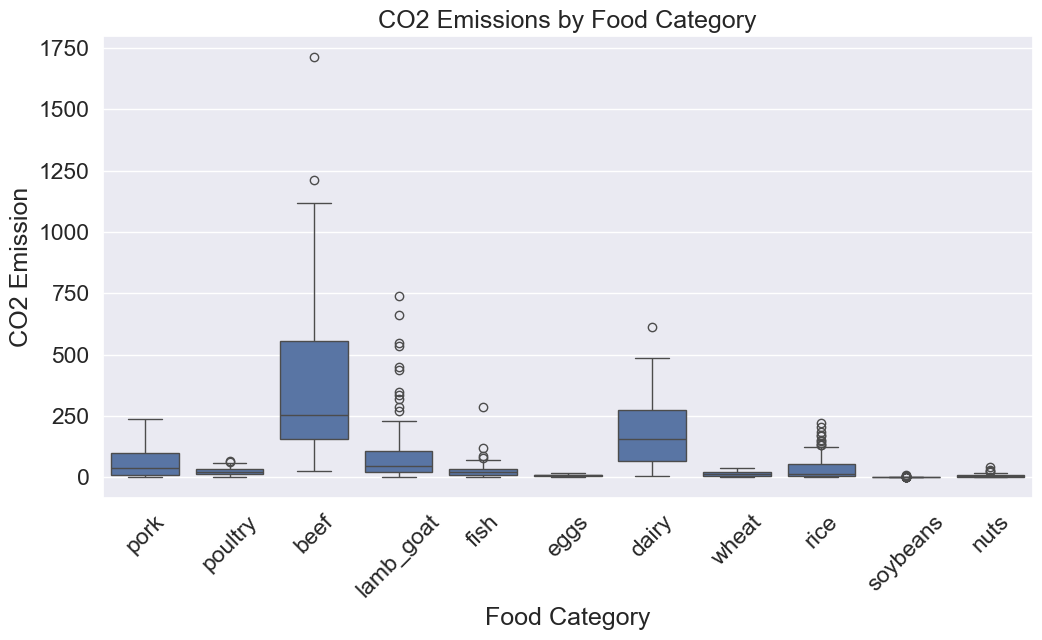

IQR by food category:
food_category
beef         399.3775
dairy        209.2725
pork          92.5200
lamb_goat     89.0375
rice          49.5500
fish          25.2700
poultry       20.2300
wheat         12.6450
eggs           7.6850
nuts           6.7350
soybeans       0.2900
Name: co2_emission, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size for better readability
plt.figure(figsize=(12, 6))

# Create a boxplot for each food category using co2_emission as the metric
sns.boxplot(data=food, x='food_category', y='co2_emission')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title("CO2 Emissions by Food Category")
plt.xlabel("Food Category")
plt.ylabel("CO2 Emission")

# Display the plot
plt.show()

# Compute the Interquartile Range (IQR) for CO2 emissions within each food category.
# The IQR is defined as Q3 (75th percentile) minus Q1 (25th percentile) and measures
# the spread of the central 50% of the data. This provides a quantitative comparison
# of variability across categories, supporting the visual interpretation of the boxplot.
iqr = food.groupby('food_category')['co2_emission'].quantile(0.75) - \
      food.groupby('food_category')['co2_emission'].quantile(0.25)

print("IQR by food category:")
print(iqr.sort_values(ascending=False))

### Final Considerations

The variability of CO₂ emissions across food categories was first explored visually using boxplots and then quantified by computing the Interquartile Range (IQR) for each category.

The IQR, defined as the difference between the 75th percentile (Q3) and the 25th percentile (Q1), provides a robust measure of variability that is not affected by extreme values.

The IQR was computed programmatically for each food category, and the results confirm that **beef** has the highest IQR among all categories.

This indicates that the middle 50% of CO₂ emission values for beef is more spread out compared to other food types, reflecting a higher variability across countries.

This result is consistent with the visual interpretation of the boxplot and may be explained by differences in production methods, supply chains, and consumption patterns in different regions.

3. Looking at the chart from the previous question, which is the `food_category` with the highest median `co2_emission` value?

### Median CO₂ Emission by Food Category

Using the boxplot created in the previous step, we now focus on identifying which food category has the highest median value of CO₂ emissions.

In a boxplot, the median is represented by the horizontal line inside each box. By comparing the position of these lines across categories, we can determine which category has the highest typical (central) CO₂ emission.

In [7]:
# Although the question refers to visual inspection,
# we can confirm the result programmatically

# Compute the median CO2 emission for each food category
median_co2 = food.groupby('food_category')['co2_emission'].median()

# Display the medians
print(median_co2)

# Identify the category with the highest median
highest_median_co2 = median_co2.idxmax()

print("Food category with highest median CO2 emission:", highest_median_co2)

food_category
beef         255.655
dairy        158.075
eggs           7.735
fish          22.270
lamb_goat     46.405
nuts           6.185
pork          36.650
poultry       21.325
rice          15.200
soybeans       0.035
wheat         13.240
Name: co2_emission, dtype: float64
Food category with highest median CO2 emission: beef


### Final Considerations

By examining the boxplot, the median CO₂ emission for each food category can be identified by the horizontal line within each box.

From the chart, the category with the highest median CO₂ emission appears to be **beef**. This indicates that, on average, beef consumption is associated with higher CO₂ emissions compared to other food categories.

This result is consistent with the known environmental impact of beef production, which typically generates significantly higher emissions than other food sources.

4. Consider the `consumption` of "poultry" and "fish" across all available `countries`; looking at the table from question 1, the average of poultry consumption (21.22) seems to be higher than that of fish consumption (17.29), but is this difference statistically significant? Create a permutation test in order to assess the null hypothesis that there is no difference between the two means. **Do you accept or reject the null hypothesis?** Explain why.

### Permutation Test: Poultry vs Fish Consumption

In this step, we assess whether the observed difference in average consumption between "poultry" and "fish" is statistically significant.

Although the mean consumption of poultry (21.22) appears higher than that of fish (17.29), we need to determine whether this difference could have occurred by chance.

To do this, we perform a permutation test under the null hypothesis that there is no difference in the mean consumption between the two food categories.

Observed difference: 3.9321538461538488
p-value: 0.0327


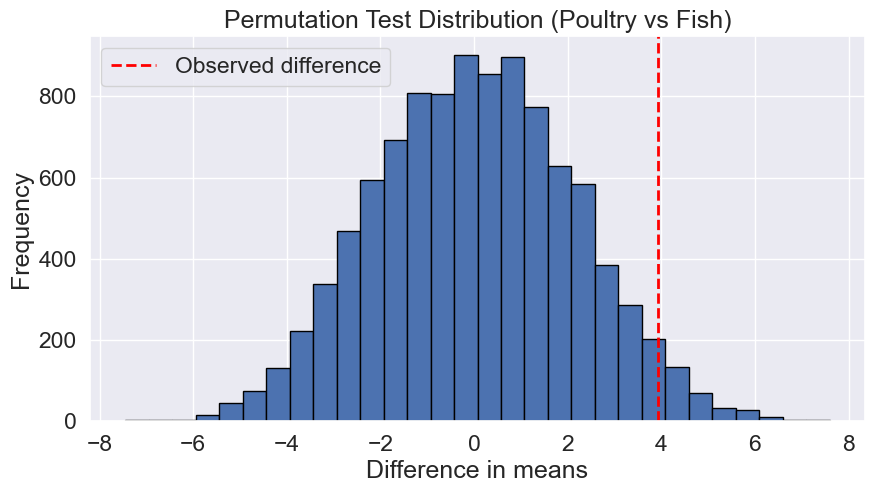

In [15]:
import numpy as np

# Extract consumption values for poultry and fish
poultry = food[food['food_category'] == 'poultry']['consumption']
fish = food[food['food_category'] == 'fish']['consumption']

# Compute the observed difference in means
observed_diff = poultry.mean() - fish.mean()
print("Observed difference:", observed_diff)

# Combine both samples into one array
combined = np.concatenate([poultry, fish])

# Set number of permutations
n_permutations = 10000

# Store simulated differences
perm_diffs = []

# Perform permutation test
for _ in range(n_permutations):
    
    # Shuffle the combined data
    shuffled = np.random.permutation(combined)
    
    # Split into two new groups of the same size
    perm_poultry = shuffled[:len(poultry)]
    perm_fish = shuffled[len(poultry):]
    
    # Compute difference in means
    diff = perm_poultry.mean() - perm_fish.mean()
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

# Compute one-sided p-value (testing if poultry > fish)
p_value = np.mean(perm_diffs >= observed_diff)

print("p-value:", p_value)


# Plot the permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=30, edgecolor='black')

# Add vertical line for observed difference
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label='Observed difference')

# Labels and title
plt.title("Permutation Test Distribution (Poultry vs Fish)")
plt.xlabel("Difference in means")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Final Considerations

A one-sided permutation test was performed to evaluate the null hypothesis that there is no difference in mean consumption between poultry and fish, against the alternative hypothesis that poultry consumption is higher than fish consumption.

The observed difference in means is approximately 3.93, with poultry showing higher average consumption than fish.

The p-value, computed as the proportion of permuted differences greater than or equal to the observed difference, is 0.0327. Since this value is lower than the chosen significance level (α = 0.05), we reject the null hypothesis.

This result indicates that the observed difference in mean consumption is unlikely to be due to random chance, providing evidence that poultry consumption is significantly higher than fish consumption across countries.

The permutation distribution provides a visual representation of the null hypothesis. The observed difference lies in the right tail of the distribution, further supporting the rejection of the null hypothesis.

### Part 2

The `distributions.csv` dataset from the `data` folder contains data drawn from 6 probability distributions – one per column. Load it to a DataFrame named `distributions` and check its contents.

### Loading and Inspecting the Distributions Dataset

The `distributions.csv` dataset contains data generated from six different probability distributions, with each column representing a distinct distribution.

In this step, the dataset is loaded into a pandas DataFrame named `distributions`. An initial exploration is then performed to understand its structure, including the variables present, their data types, and a preview of the data.

In [9]:
import pandas as pd

# Load the dataset into a DataFrame
distributions = pd.read_csv("data/distributions.csv")

# Display the first few rows to inspect the structure and contents
print(distributions.head())

# Display general information about the dataset:
# - column names
# - data types
# - number of non-null values
print(distributions.info())

# Generate summary statistics for numerical columns
print(distributions.describe())

# Check column names (each one represents a distribution)
print(distributions.columns)

   distribution_1  distribution_2  distribution_3  distribution_4  \
0           False      100.004134        3.608307             890   
1           False      100.008868        5.785856             897   
2           False      100.004402        4.785344             898   
3           False      100.000589        5.712047             890   
4           False      100.017889        4.240379             898   

   distribution_5  distribution_6  distribution_7  
0               1             -34        0.563827  
1               1             -35        1.441859  
2               3             -37        0.347664  
3               0             -34        3.039330  
4               1             -35        0.089587  
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   distribution_1  1000 non-null   bool   
 1   distribution_2  1000 non-null   float64

### Final Considerations

The dataset has been successfully loaded into a DataFrame named `distributions`. It contains 1,000 observations and 7 variables, each representing a different probability distribution.

All columns are complete, with no missing values. Most variables are numerical, while `distribution_1` is a boolean variable, indicating that it likely represents a binary distribution.

The summary statistics reveal different characteristics across the variables. For example, `distribution_2` is tightly centered around 100 with a very small standard deviation, suggesting a low-variance continuous distribution. In contrast, `distribution_3` shows greater variability, while `distribution_4`, `distribution_5`, and `distribution_6` contain integer values, indicating discrete distributions.

Additionally, `distribution_7` contains continuous values with a wider spread and some extreme values, suggesting a skewed distribution.

Overall, the dataset is well-structured and suitable for further analysis, particularly for identifying the underlying probability distributions through visualization.

1. Use the `.describe()` and `info()` methods on the `distributions` DataFrame to produce some preliminary information about each column. **What is the data type of each column?**

### Data Types and Structure of the Distributions Dataset

In this step, we explore the structure of the `distributions` DataFrame using the `.info()` and `.describe()` methods. 

The goal is to understand the data type of each column, as well as to gain preliminary insights into the nature of the variables, such as whether they are continuous, discrete, or binary.

In [10]:
# Display general information about the dataset:
# - column names
# - data types
# - number of non-null values
distributions.info()

# Generate summary statistics for numerical columns
print(distributions.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   distribution_1  1000 non-null   bool   
 1   distribution_2  1000 non-null   float64
 2   distribution_3  1000 non-null   float64
 3   distribution_4  1000 non-null   int64  
 4   distribution_5  1000 non-null   int64  
 5   distribution_6  1000 non-null   int64  
 6   distribution_7  1000 non-null   float64
dtypes: bool(1), float64(3), int64(3)
memory usage: 48.0 KB
       distribution_2  distribution_3  distribution_4  distribution_5  \
count     1000.000000     1000.000000     1000.000000     1000.000000   
mean       100.000263        3.462706      899.630000        1.192000   
std          0.010155        1.466874        9.729531        1.091938   
min         99.961668        1.002417      865.000000        0.000000   
25%         99.993916        2.223423      893.000000        0.000000   
50%

### Final Considerations

The `distributions` DataFrame contains 7 columns, each representing a different probability distribution, and 1,000 observations.

From the `.info()` output, we can identify the data types of each column:

- `distribution_1`: bool
- `distribution_2`: float64
- `distribution_3`: float64
- `distribution_4`: int64
- `distribution_5`: int64
- `distribution_6`: int64
- `distribution_7`: float64

This indicates that the dataset includes a mix of variable types. Specifically, `distribution_1` is a binary variable, `distribution_4`, `distribution_5`, and `distribution_6` are discrete numerical variables, and the remaining columns are continuous variables.

The `.describe()` output provides additional insight into the central tendency and variability of the numerical distributions, which will be useful for identifying their underlying probability distributions in subsequent analysis.

2. Loop through each column of `distributions` and for each column produce a plot to show the distribution.

### Visualizing Each Distribution

In this step, we loop through all columns of the `distributions` DataFrame and create one plot for each variable.

Since each column represents data drawn from a probability distribution, histograms are useful to visualize the shape, spread, and possible skewness of each distribution.

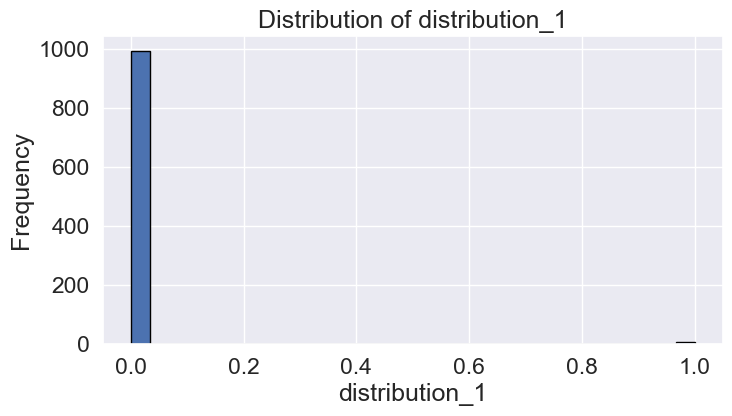

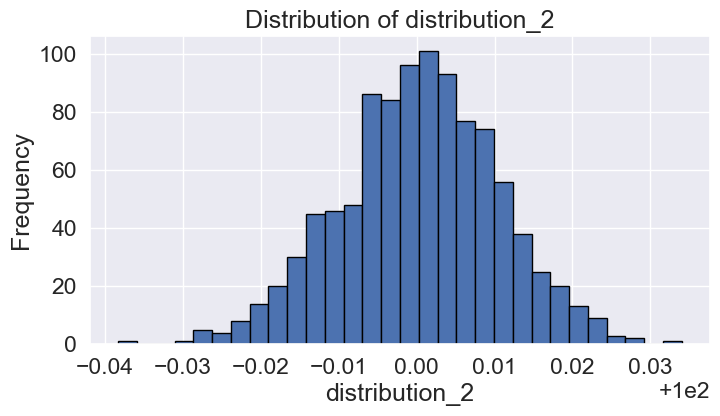

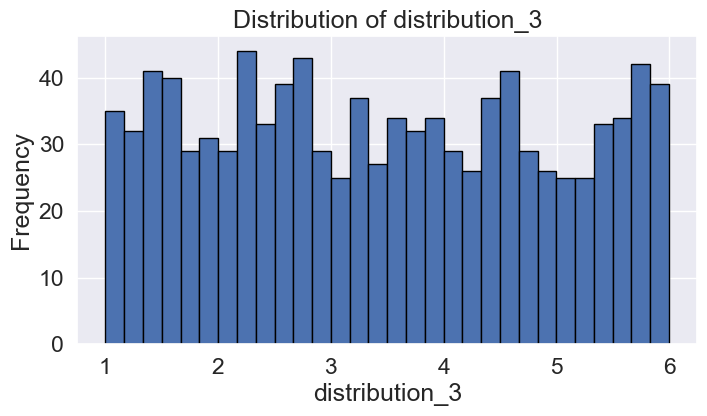

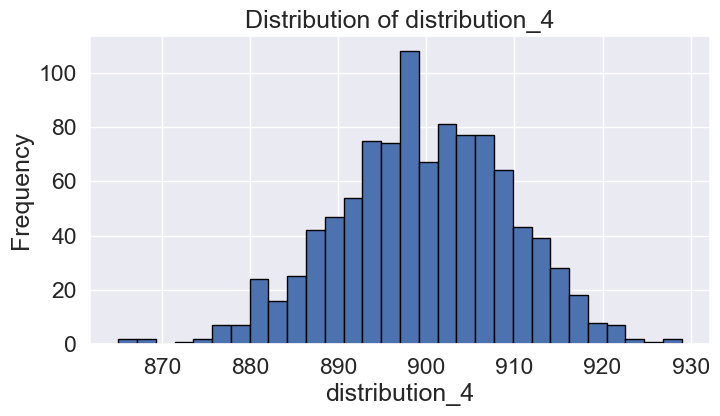

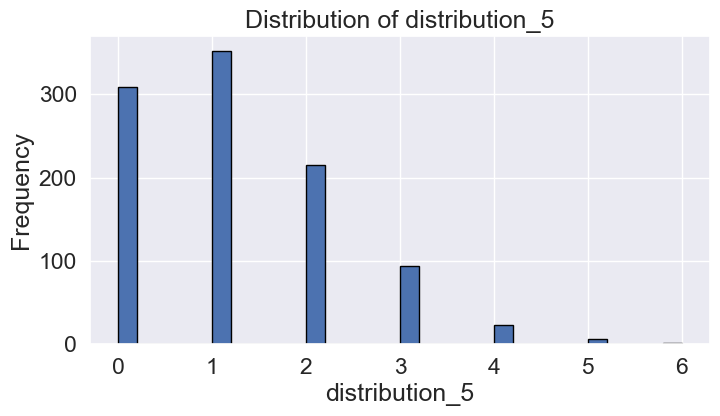

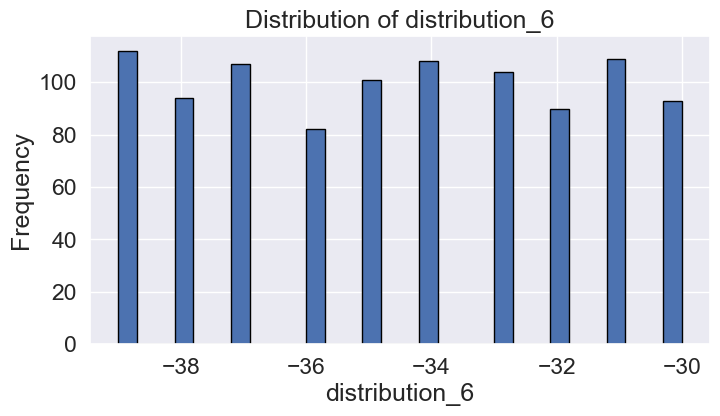

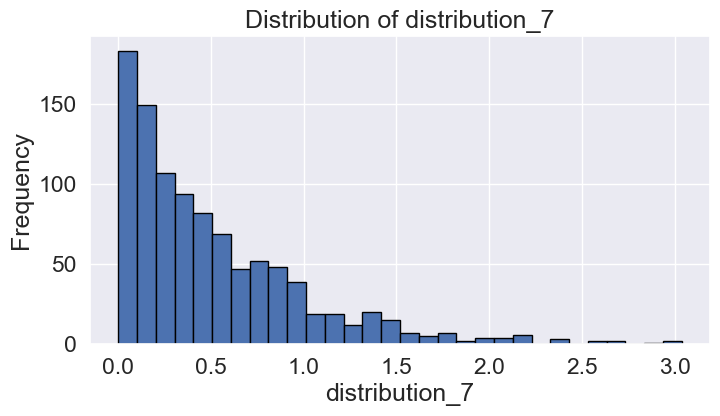

In [12]:
import matplotlib.pyplot as plt

# Loop through each column in the distributions DataFrame
for col in distributions.columns:
    
    # Create a new figure for each distribution
    plt.figure(figsize=(8, 4))
    
    # If the column is boolean, convert True/False to 1/0
    if distributions[col].dtype == bool:
        data = distributions[col].astype(int)
    else:
        data = distributions[col]
    
    # Plot a histogram for the current column
    plt.hist(data, bins=30, edgecolor='black')
    
    # Add title and axis labels
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    # Display the plot
    plt.show()

### Final Considerations

The loop produces one histogram for each column in the `distributions` DataFrame.

These plots allow us to visually inspect the shape of each variable and compare their distributional patterns. Some columns may show continuous distributions, while others may appear discrete or binary.

This graphical analysis is useful for identifying which theoretical probability distribution each column may come from in the next step.

3. Each column of the `distributions` dataframe contains data drawn from a different distribution. **Associate each column to its probability distribution.** This is the list of the probability distributions used (one for each column):
    - Bernoulli
    - Binomial
    - Continuous Uniform
    - Gaussian (Normal)
    - Discrete Uniform
    - Poisson
    - Exponential (this was not explain in classroom, go by exclusion)

### Identifying Probability Distributions

In this step, we analyze the shape and characteristics of each column in the `distributions` DataFrame in order to associate them with their corresponding probability distributions.

By combining information from the summary statistics and the histograms generated in the previous step, we can infer whether each variable is binary, discrete, or continuous, and match it with the appropriate theoretical distribution.

In [17]:
# Although the classification is mainly based on visual inspection,
# we can review summary statistics again to support our reasoning

print(distributions.describe())

# --- Quantitative check for Normal distribution (distribution_2) ---
# For a Gaussian distribution, mean and median are expected to be approximately equal
mean_val = distributions['distribution_2'].mean()
median_val = distributions['distribution_2'].median()

print("\nDistribution_2 - Mean:", mean_val)
print("Distribution_2 - Median:", median_val)

# --- Quantitative check for discrete vs continuous variables ---
# Discrete distributions usually have a limited number of unique values,
# while continuous distributions usually have many unique values
print("\nNumber of unique values by column:")
for col in distributions.columns:
    print(f"{col}: {distributions[col].nunique()} unique values")

# --- Quantitative check for Poisson distribution (distribution_5) ---
# For a Poisson distribution, the mean and variance are expected to be approximately equal
poisson_mean = distributions['distribution_5'].mean()
poisson_variance = distributions['distribution_5'].var()

print("\nDistribution_5 - Mean:", poisson_mean)
print("Distribution_5 - Variance:", poisson_variance)

# --- Quantitative check for Exponential distribution (distribution_7) ---
# Exponential distributions are continuous, positive, and typically right-skewed
exp_min = distributions['distribution_7'].min()
exp_skewness = distributions['distribution_7'].skew()

print("\nDistribution_7 - Minimum:", exp_min)
print("Distribution_7 - Skewness:", exp_skewness)

# Check sample unique values for each column to better understand their behavior
print("\nSample unique values by column:")
for col in distributions.columns:
    print(f"\nUnique values for {col}:")
    print(distributions[col].unique()[:10])  # print only first 10 values

       distribution_2  distribution_3  distribution_4  distribution_5  \
count     1000.000000     1000.000000     1000.000000     1000.000000   
mean       100.000263        3.462706      899.630000        1.192000   
std          0.010155        1.466874        9.729531        1.091938   
min         99.961668        1.002417      865.000000        0.000000   
25%         99.993916        2.223423      893.000000        0.000000   
50%        100.000598        3.426250      900.000000        1.000000   
75%        100.007031        4.679788      906.000000        2.000000   
max        100.034052        5.997595      929.000000        6.000000   

       distribution_6  distribution_7  
count     1000.000000     1000.000000  
mean       -34.539000        0.513223  
std          2.889087        0.497540  
min        -39.000000        0.000033  
25%        -37.000000        0.141789  
50%        -34.000000        0.362279  
75%        -32.000000        0.735851  
max        -30.000000 

### Final Considerations

Based on the visual inspection of the histograms and the summary statistics, each column can be associated with a specific probability distribution:

- `distribution_1`: **Bernoulli**  
  This column contains binary values (True/False), indicating a Bernoulli distribution.

- `distribution_2`: **Gaussian (Normal)**  
  The distribution is continuous, symmetric, and bell-shaped, centered around its mean.

- `distribution_3`: **Continuous Uniform**  
  The values are evenly distributed across a continuous range, resulting in a flat histogram.

- `distribution_4`: **Binomial**  
  The values are discrete and concentrated around a central value, forming a shape similar to a normal distribution due to a large number of trials.

- `distribution_5`: **Poisson**  
  The values are discrete and right-skewed, with most observations concentrated at lower integers.

- `distribution_6`: **Discrete Uniform**  
  The values are discrete and uniformly distributed across a fixed integer range.

- `distribution_7`: **Exponential**  
  The distribution is continuous and highly right-skewed, with many small values and a long tail.

These assignments are based on the characteristic shapes observed in the histograms and the nature of the data in each column.

## Limitations and Assumptions

While the analysis provides useful insights, it is important to acknowledge some limitations:

- The dataset may not fully represent all countries or consumption patterns globally.
- The permutation test assumes that observations are exchangeable under the null hypothesis.
- CO₂ emissions may be influenced by external factors not included in the dataset, such as production technology or supply chain differences.
- The classification of distributions is partly based on visual inspection and limited quantitative checks.

These limitations should be considered when interpreting the results, and further analysis could improve robustness by incorporating additional variables and more formal statistical tests.

## Final Conclusion

This analysis combined exploratory data analysis and statistical inference to investigate food consumption and CO₂ emissions.

The results highlight both variability across food categories and statistically significant differences in consumption patterns. By integrating visual inspection with quantitative validation, the analysis ensures robust and interpretable conclusions.

Overall, the approach demonstrates how data-driven methods can be used to extract meaningful insights while maintaining awareness of underlying assumptions and limitations.